In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread("./image.jpg")
rgbImg = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
grayImg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# laplacian -> cek segala arah
# 0 1 0
# 1 -4 1
# 0 1 0

laplaciImg = cv2.Laplacian(grayImg, cv2.CV_64F)


### How the Laplacian Operator Works

The Laplacian is a 2D isotropic measure of the 2nd spatial derivative of an image. It highlights regions of rapid intensity change and is therefore often used for edge detection.

1. **First Derivative:** Measures the rate of change of pixel intensity. A peak in the first derivative indicates an edge.
2. **Second Derivative:** Measures the rate of change of the first derivative. A zero-crossing (where the value goes from positive to negative or vice versa) in the second derivative indicates the exact location of an edge.

The Laplacian operator calculates this second derivative in both the x and y directions simultaneously.

**The Kernel:**
The standard 3x3 Laplacian kernel looks like this:
```
[ 0  1  0 ]
[ 1 -4  1 ]
[ 0  1  0 ]
```
When this kernel is convolved with an image, it essentially compares the intensity of a central pixel with the average intensity of its four immediate neighbors (top, bottom, left, right). 

*   If the central pixel is similar to its neighbors, the result is close to zero (flat region).
*   If the central pixel is significantly different from its neighbors, the result is a large positive or negative value (an edge).

**Why `cv2.CV_64F`?**
Because the Laplacian involves subtraction, the result can be negative (e.g., transitioning from a bright area to a dark area). Standard 8-bit unsigned integers (`uint8`) cannot store negative numbers and would clip them to 0. Using a 64-bit float (`cv2.CV_64F`) preserves these negative values, which are crucial for finding the zero-crossings.

In [3]:
sobelX = cv2.Sobel(grayImg, cv2.CV_64F, 1, 0, 3)
sobelY = cv2.Sobel(grayImg, cv2.CV_64F, 0, 1, 3)

### How the Sobel Operator Works

The Sobel operator is a discrete differentiation operator used to compute an approximation of the gradient of the image intensity function. Unlike the Laplacian (which calculates the 2nd derivative), Sobel calculates the **1st derivative** to find the direction and magnitude of edges.

It uses two separate 3x3 kernels to calculate the derivatives in the horizontal (X) and vertical (Y) directions.

#### 1. Sobel X (Horizontal Derivative)
Sobel X calculates the difference in pixel intensities from left to right. Because it measures horizontal changes, it is used to detect **vertical edges**.

**Sobel X Kernel:**
```
[-1  0  1]
[-2  0  2]
[-1  0  1]
```
*Notice how the left side is negative and the right side is positive. When convolved with an image, it subtracts the pixels on the left from the pixels on the right. If there is a sharp change (a vertical edge), the result will be a high value.*

#### 2. Sobel Y (Vertical Derivative)
Sobel Y calculates the difference in pixel intensities from top to bottom. Because it measures vertical changes, it is used to detect **horizontal edges**.

**Sobel Y Kernel:**
```
[-1 -2 -1]
[ 0  0  0]
[ 1  2  1]
```
*Here, the top is negative and the bottom is positive. It subtracts the pixels above from the pixels below, highlighting horizontal edges.*

#### Why the 1, 2, 1 weighting?
You might notice the numbers are not just 1s and -1s. The center row/column has a weight of 2 (or -2). This is because the Sobel operator combines differentiation with **Gaussian smoothing**. The heavier weight in the center gives more importance to the central pixels, which helps to reduce the effect of noise in the image while still detecting the edge.

#### Combining X and Y
To get the full picture of all edges (both horizontal and vertical), you typically calculate both Sobel X and Sobel Y, and then combine them to find the total gradient magnitude:
$G = \sqrt{G_x^2 + G_y^2}$

In [4]:
mag = np.sqrt(sobelX**2 + sobelY**2)

In [5]:
# Canny Edge Detection
cannyImg = cv2.Canny(grayImg, 100, 200)

### How Canny Edge Detection Works

The Canny edge detector is a multi-stage algorithm designed to detect a wide range of edges in images while minimizing noise. It is widely considered the standard edge detection method because it produces clean, thin, and continuous edges.

It works in 4 main steps:

#### 1. Noise Reduction (Gaussian Blur)
Since edge detection is highly susceptible to noise in the image, the first step is to remove noise using a Gaussian filter. This smooths the image slightly.

#### 2. Finding the Intensity Gradient (Sobel)
The smoothed image is then filtered with a Sobel kernel in both horizontal and vertical directions to get the first derivative in the horizontal direction ($G_x$) and vertical direction ($G_y$). From these two images, we can find the edge gradient and direction for each pixel:
*   **Edge Gradient ($G$):** $\sqrt{G_x^2 + G_y^2}$
*   **Angle ($\theta$):** $\tan^{-1}(\frac{G_y}{G_x})$

#### 3. Non-Maximum Suppression
After getting the gradient magnitude and direction, a full scan of the image is done to remove any unwanted pixels which may not constitute the edge. For every pixel, it checks if it is a local maximum in its neighborhood in the direction of the gradient. 
*   If it is the maximum, it is kept.
*   If it is not, it is suppressed (set to zero).
*This step ensures that the edges are thin (only one pixel wide).*

#### 4. Hysteresis Thresholding
This stage decides which edges are really edges and which are not. For this, we need two threshold values, `minVal` and `maxVal` (the parameters `100` and `200` in your code).
*   Any edges with an intensity gradient more than `maxVal` are sure to be edges (strong edges).
*   Any edges with an intensity gradient below `minVal` are sure to be non-edges, so they are discarded.
*   Those lying between these two thresholds are classified as edges or non-edges based on their connectivity. If they are connected to "sure-edge" pixels, they are considered part of the edge. Otherwise, they are also discarded.

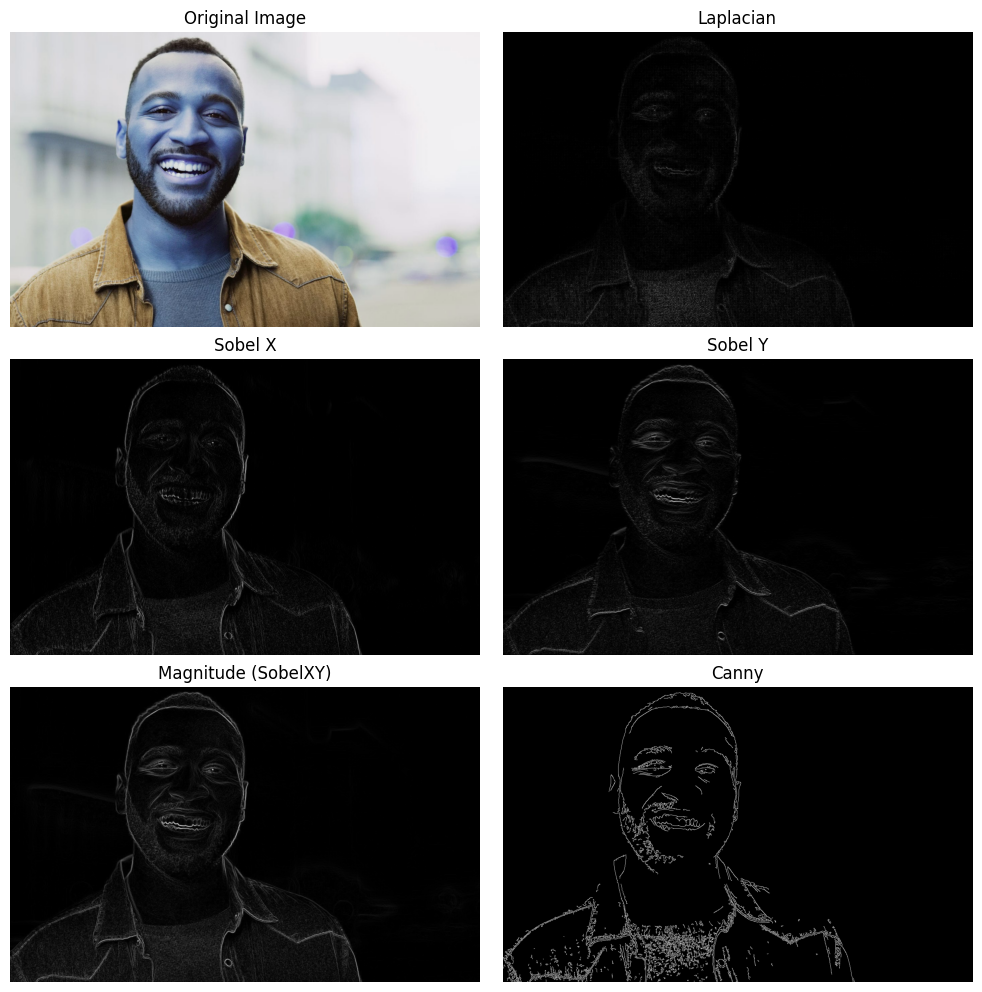

In [6]:
images = {
    "Original Image": img,
    "Laplacian": np.abs(laplaciImg),
    "Sobel X": np.abs(sobelX),
    "Sobel Y": np.abs(sobelY),
    "Magnitude (SobelXY)" : np.abs(mag),
    "Canny": np.abs(cannyImg)
}

plt.figure(figsize=(10, 10))

for i, (title, img_data) in enumerate(images.items()):
    plt.subplot(3, 2, i + 1)

    cmap = None if title == "Original Image" else "gray"

    plt.imshow(img_data, cmap=cmap)
    plt.axis("off")
    plt.title(title)

plt.tight_layout()
plt.show()

In [ ]:
img = cv2.imread("./image.jpg")
cv2.imshow("Image", img)